In [13]:
from matplotlib import pyplot as plt
import numpy as np
from src.utils.data_processing import load_data_base,add_demog_features
import seaborn as sns


In [ ]:
# Notebook d'exploration des données

# Objectifs :
# - Analyser la structure des jeux de données train/test
# - Vérifier l'absence de split temporel
# - Identifier les données manquantes et les anomalies potentielles

# Analyses réalisées :
# - Étude de la répartition des observations par année
#   -> Le jeu de test apparaît globalement équilibré sur les années,
#      ce qui suggère l'absence de séparation temporelle entre train et test.

# - Analyse des valeurs manquantes

# - Détection d'anomalies dans certaines variables :
#   - WeeklyWages = 1
#   - HoursWorkedPerWeek = 0
#   - autres valeurs atypiques

# Remarque :
# Les anomalies identifiées ont été documentées mais ne sont pas corrigées

In [2]:
dossier="/home/tiphainell/Documents/5.Direct Assurance/actuarial-loss-estimation"

In [3]:
database=load_data_base(dossier)
#format database
database=add_demog_features(database)


In [4]:
#vérification données manquantes ou non, type de données sur les données numériques
database.describe()

,Age,DependentChildren,DependentsOther,WeeklyWages,HoursWorkedPerWeek,DaysWorkedPerWeek,InitialIncurredCalimsCost,UltimateIncurredClaimCost,DateTimeOfAccident_year,DateTimeOfAccident_month,DateTimeOfAccident_day,DateTimeOfAccident_hour,DateTimeOfAccident_week,reporting_delay,wages_per_hour,claim_given_wages,relative_wage,age_2
count,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,9.000000e+04,5.400000e+04,90000.000000,90000.000000,90000.000000,90000.000000,90000.0,90000.000000,90000.000000,9.000000e+04,90000.000000,90000.00000
mean,33.848044,0.119511,0.009811,416.369865,37.744587,4.908422,7.776410e+03,1.100337e+04,1996.500000,6.505578,15.617244,11.572056,26.572511,38.105800,11.321448,1.658535e+03,0.034680,1292.65560
std,12.123000,0.519645,0.108952,246.196704,12.325391,0.547494,1.941012e+04,3.339099e+04,5.188156,3.402471,8.725739,3.743689,14.802449,59.796824,7.965037,5.207681e+04,0.025644,912.89795
min,13.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000e+00,1.218868e+02,1988.000000,1.000000,1.000000,0.000000,1.0,-1.000000,0.014286,6.000000e-03,0.000037,169.00000
25%,23.000000,0.000000,0.000000,200.000000,38.000000,5.000000,6.610000e+02,9.263384e+02,1992.000000,4.000000,8.000000,9.000000,14.0,13.000000,5.714286,8.000000e+01,0.023957,529.00000
50%,32.000000,0.000000,0.000000,393.300000,38.000000,5.000000,2.000000e+03,3.371242e+03,1996.500000,7.000000,16.000000,11.000000,27.0,21.000000,10.570111,2.099104e+02,0.026875,1024.00000
75%,43.000000,0.000000,0.000000,500.000000,40.000000,5.000000,9.500000e+03,8.197249e+03,2001.000000,9.000000,23.000000,14.000000,40.0,40.000000,13.563571,7.702662e+02,0.039587,1849.00000
max,81.000000,9.000000,5.000000,7497.000000,700.000000,7.000000,2.000000e+06,4.027136e+06,2005.000000,12.000000,31.000000,23.000000,53.0,1094.000000,519.200000,1.380000e+07,1.887177,6561.00000


In [5]:
database.groupby('role')['Gender'].value_counts(normalize=True)
#il n'y pas de undefined dans le test, sinon les proportions sont respectées entre le train et le test

role   Gender
test   M         0.775167
       F         0.224833
train  M         0.771481
       F         0.228481
       U         0.000037
Name: proportion, dtype: float64

In [6]:
database.groupby('role')['MaritalStatus'].value_counts(normalize=True)

role   MaritalStatus
test   S                0.486716
       M                0.417403
       U                0.095881
train  S                0.484723
       M                0.417187
       U                0.098090
Name: proportion, dtype: float64

In [7]:

database.groupby('role')['PartTimeFullTime'].value_counts(normalize=True)

role   PartTimeFullTime
test   F                   0.912056
       P                   0.087944
train  F                   0.909481
       P                   0.090519
Name: proportion, dtype: float64

In [8]:
database.groupby('role')['DateTimeOfAccident_year'].value_counts(normalize=True)
# Le test et le train sont équilibrés en terme d'années entre 1988 et 2005 
# Il n'y a pas de split temporel, c'est un random split, à reproduire pour le validation, split random

role   DateTimeOfAccident_year
test   1998                       0.056556
       1990                       0.056361
       1991                       0.056306
       1989                       0.056194
       2003                       0.056167
       1994                       0.056083
       1995                       0.056028
       2000                       0.055750
       2005                       0.055639
       1999                       0.055583
       1993                       0.055472
       2002                       0.055250
       1992                       0.054944
       1988                       0.054917
       2001                       0.054778
       1997                       0.054694
       2004                       0.054667
       1996                       0.054611
train  1996                       0.056185
       2004                       0.056148
       1997                       0.056130
       2001                       0.056074
       1988            

In [ ]:
# Analyse du train seul : performance du initial claim, distribution des logs de claims, impact de l'inflation

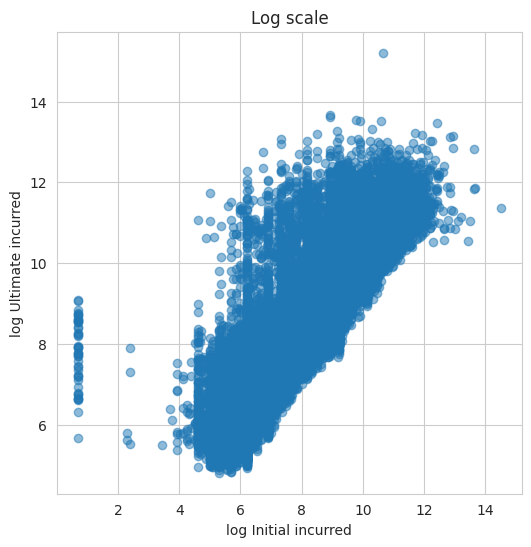

In [9]:
plt.figure(figsize=(6,6))

train=database[database['role']=='train']

plt.scatter(
    np.log1p(train["InitialIncurredCalimsCost"]),
    np.log1p(train["UltimateIncurredClaimCost"]),
    alpha=0.5
)

plt.xlabel("log Initial incurred")
plt.ylabel("log Ultimate incurred")
plt.title("Log scale")
plt.show()

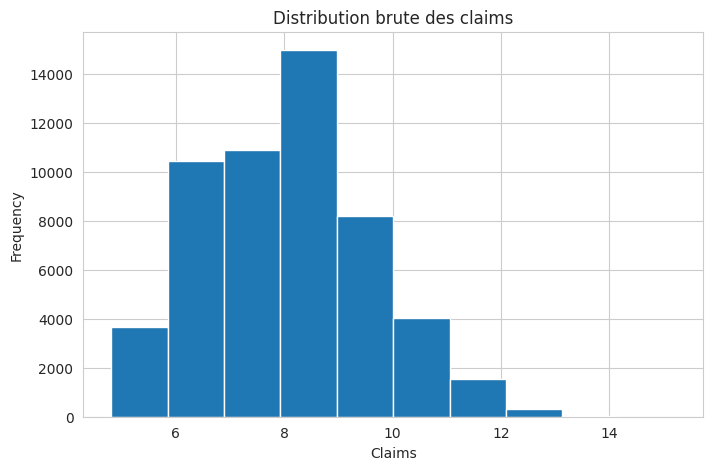

In [16]:
#Distribution des logs des claims
# 

plt.figure(figsize=(8,5))
plt.hist(np.log1p(train["UltimateIncurredClaimCost"]))
plt.title("Distribution brute des claims")
plt.xlabel("Claims")
plt.ylabel("Frequency")
plt.show()

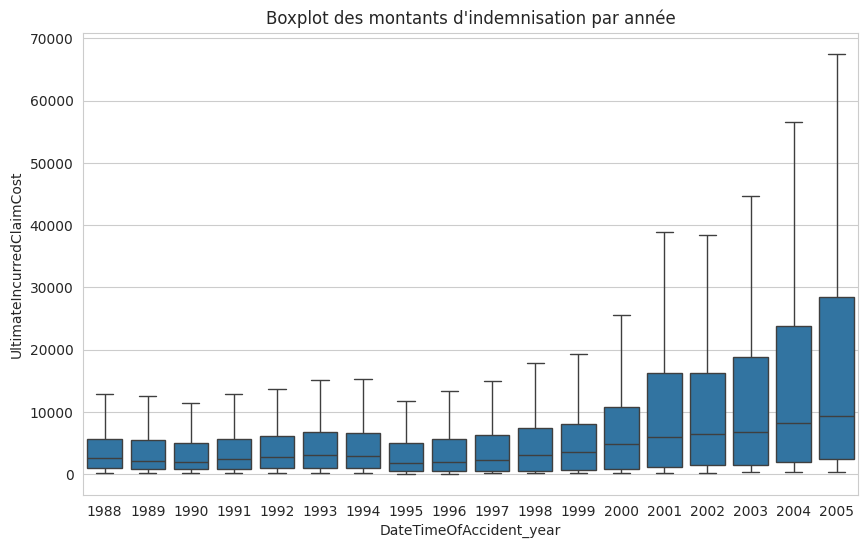

In [15]:
#montant d'indemnisation selon les années
#on voit l'effet de l'inflation sur les années

plt.figure(figsize=(10, 6))
sns.boxplot(data=train, x="DateTimeOfAccident_year", y="UltimateIncurredClaimCost",showfliers=False)

plt.title("Boxplot des montants d'indemnisation par année")
plt.show()